In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("../DATA/Metro_Interstate_Traffic_Volume.csv")
print(df.shape)
df.head()

(48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [6]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [7]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [8]:
df['holiday']=df['holiday'].fillna("None")

In [9]:
df.isnull().sum()

holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64

In [11]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour']       = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek   # 0=Monday, 6=Sunday
df['month']      = df['date_time'].dt.month
df['year']       = df['date_time'].dt.year
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

print(df[['date_time','hour','day_of_week','month','is_weekend']].head(10))

            date_time  hour  day_of_week  month  is_weekend
0 2012-10-02 09:00:00     9            1     10           0
1 2012-10-02 10:00:00    10            1     10           0
2 2012-10-02 11:00:00    11            1     10           0
3 2012-10-02 12:00:00    12            1     10           0
4 2012-10-02 13:00:00    13            1     10           0
5 2012-10-02 14:00:00    14            1     10           0
6 2012-10-02 15:00:00    15            1     10           0
7 2012-10-02 16:00:00    16            1     10           0
8 2012-10-02 17:00:00    17            1     10           0
9 2012-10-02 18:00:00    18            1     10           0


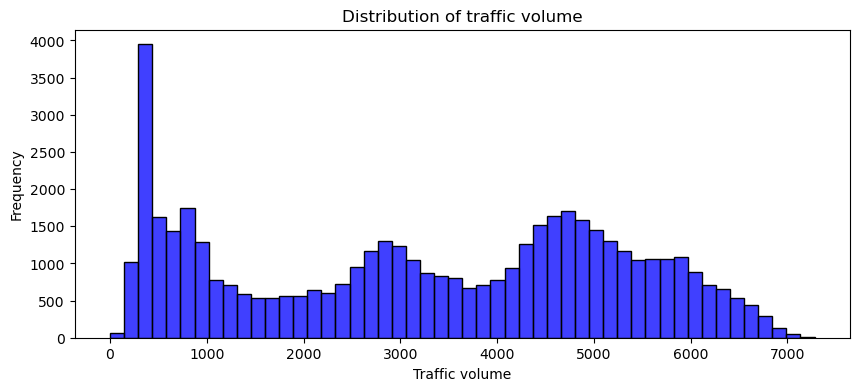

In [12]:
plt.figure(figsize=(10,4))
sns.histplot(df['traffic_volume'],bins=50,color='blue')
plt.title('Distribution of traffic volume')
plt.xlabel('Traffic volume')
plt.ylabel('Frequency')
plt.show()

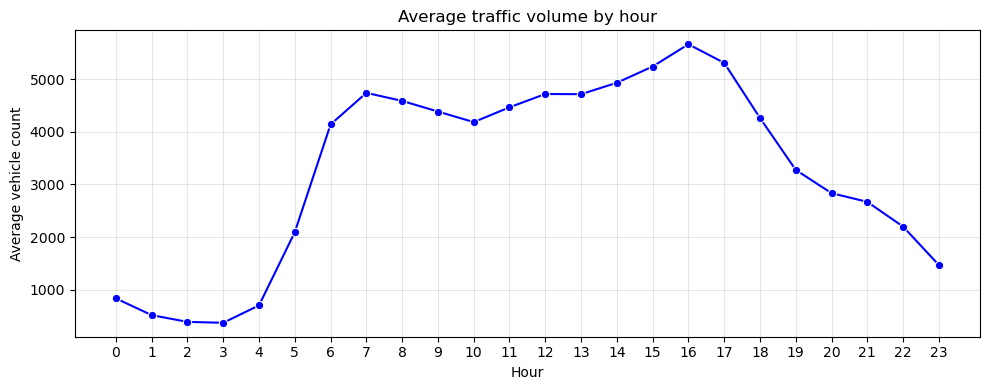

In [15]:
## Average traffic by hour
hourly=df.groupby('hour')['traffic_volume'].mean()
plt.figure(figsize=(10,4))
sns.lineplot(x=hourly.index,y=hourly.values,marker='o',color='blue')
plt.title('Average traffic volume by hour')
plt.xlabel('Hour')
plt.ylabel('Average vehicle count')
plt.xticks(range(0,24))
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

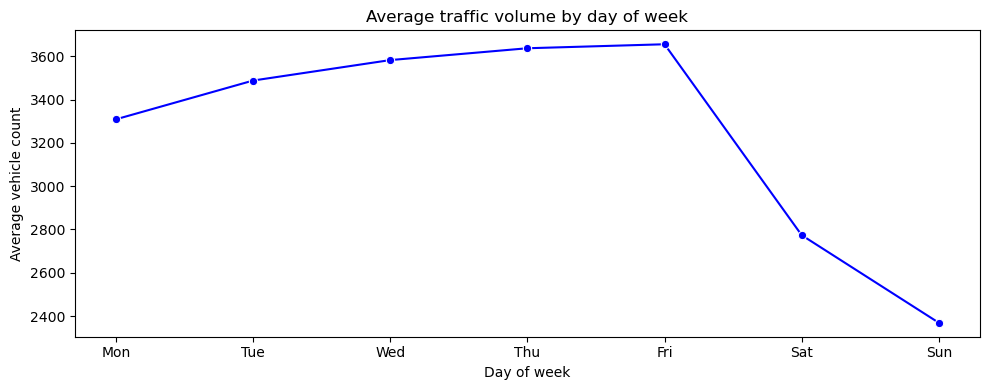

In [16]:
## traffic by day of week
days=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily=df.groupby('day_of_week')['traffic_volume'].mean()
plt.figure(figsize=(10,4))
sns.lineplot(x=days,y=daily.values,marker='o',color='blue')
plt.title('Average traffic volume by day of week')
plt.xlabel('Day of week')
plt.ylabel('Average vehicle count')
plt.tight_layout()
plt.show()

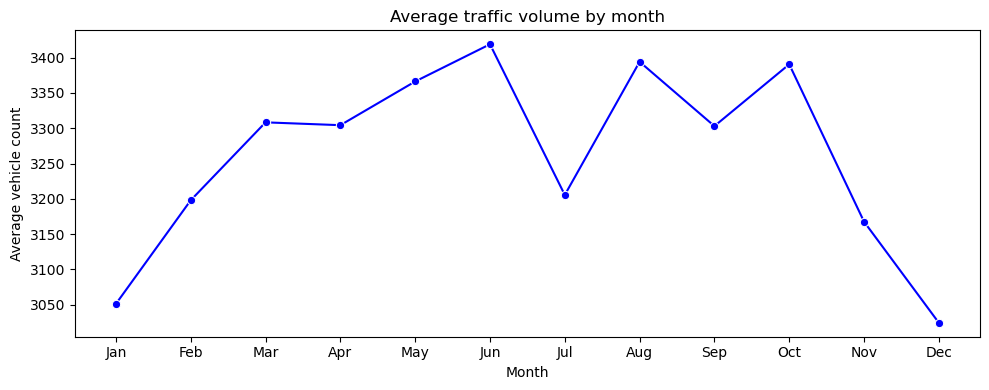

In [17]:
## traffic by month
months=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly=df.groupby('month')['traffic_volume'].mean()
plt.figure(figsize=(10,4))
sns.lineplot(x=months,y=monthly.values,marker='o',color='blue')
plt.title('Average traffic volume by month')
plt.xlabel('Month')
plt.ylabel('Average vehicle count')
plt.tight_layout()
plt.show()

C:\Users\rdey1\AppData\Local\Temp\ipykernel_26300\1351974751.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_traffic.index,y=weather_traffic.values,palette='viridis')


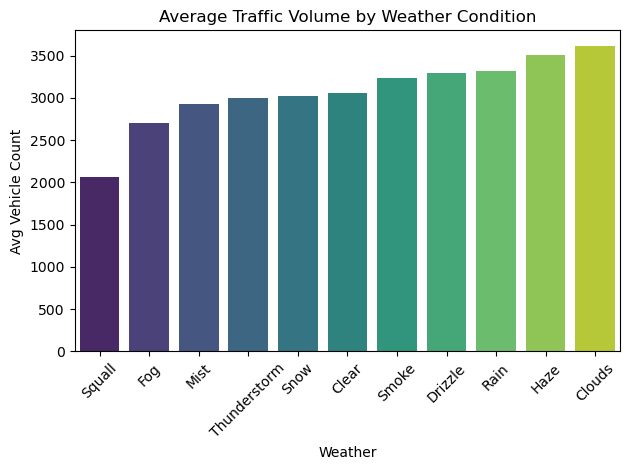

In [19]:
## weather impact on traffic
weather_traffic=df.groupby('weather_main')['traffic_volume'].mean().sort_values()
sns.barplot(x=weather_traffic.index,y=weather_traffic.values,palette='viridis')
plt.title("Average Traffic Volume by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Avg Vehicle Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


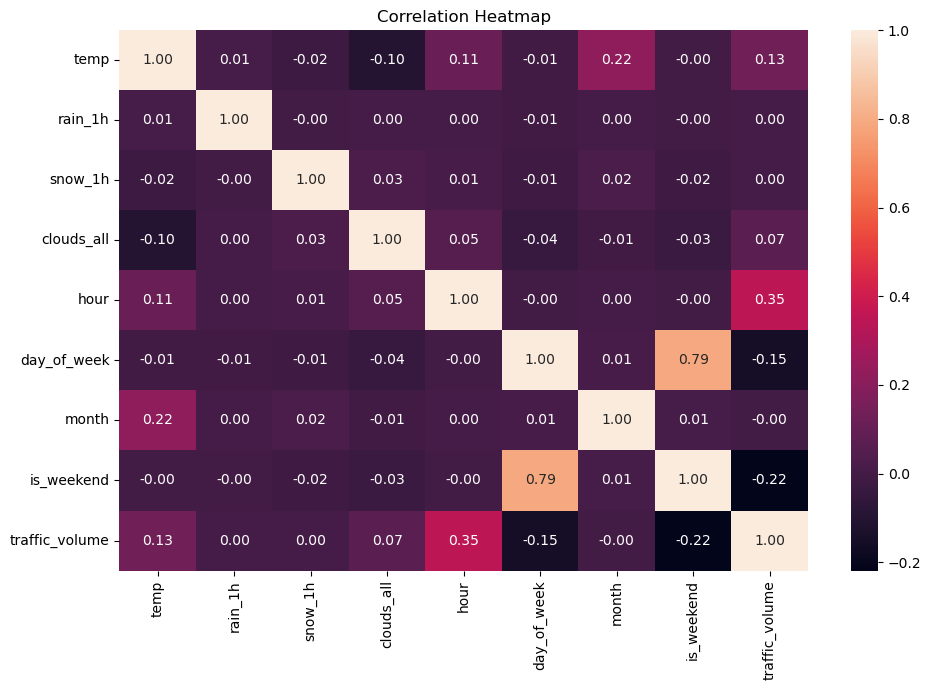

In [22]:
numeric_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all','hour', 'day_of_week', 'month', 'is_weekend', 'traffic_volume']

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [23]:
df=df.drop_duplicates()

In [24]:
df.shape

(48187, 14)

In [25]:
# 1 = it's a holiday, 0 = regular day
df['is_holiday'] = df['holiday'].apply(lambda x: 0 if x == "None" else 1)

print(df['is_holiday'].value_counts())
# Expected: 0 → ~48143, 1 → ~61 (holidays are rare!)

is_holiday
0    48126
1       61
Name: count, dtype: int64


In [27]:
df.tail()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,year,is_weekend,is_holiday
48199,None,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543,19,6,9,2018,1,0
48200,None,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781,20,6,9,2018,1,0
48201,None,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159,21,6,9,2018,1,0
48202,None,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450,22,6,9,2018,1,0
48203,None,282.12,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 23:00:00,954,23,6,9,2018,1,0


PHASE 3 - EDA


In [28]:
df=df.drop(columns=['holiday','date_time','weather_description'])
df.shape


(48187, 12)

In [29]:
df.head()

,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,hour,day_of_week,month,year,is_weekend,is_holiday
0,288.28,0.0,0.0,40,Clouds,5545,9,1,10,2012,0,0
1,289.36,0.0,0.0,75,Clouds,4516,10,1,10,2012,0,0
2,289.58,0.0,0.0,90,Clouds,4767,11,1,10,2012,0,0
3,290.13,0.0,0.0,90,Clouds,5026,12,1,10,2012,0,0
4,291.14,0.0,0.0,75,Clouds,4918,13,1,10,2012,0,0


In [30]:
# One-hot encode weather_main
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

print(df.shape)
print(df.columns.tolist())

(48187, 21)
['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday', 'weather_main_Clouds', 'weather_main_Drizzle', 'weather_main_Fog', 'weather_main_Haze', 'weather_main_Mist', 'weather_main_Rain', 'weather_main_Smoke', 'weather_main_Snow', 'weather_main_Squall', 'weather_main_Thunderstorm']


In [32]:
# Convert temp from Kelvin to Celsius
df['temp'] = df['temp'] - 273.15

# Fix: use round() as a built-in function instead
print("Temp range (°C):", round(df['temp'].min(), 2), "to", round(df['temp'].max(), 2))

Temp range (°C): -546.3 to -236.23


In [33]:
# Check how many rows have extreme rain/snow values
print("Rain > 100mm:", (df['rain_1h'] > 100).sum())
print("Snow > 10mm:",  (df['snow_1h'] > 10).sum())

# Cap extreme outliers (they are likely sensor errors)
df['rain_1h'] = df['rain_1h'].clip(upper=100)
df['snow_1h'] = df['snow_1h'].clip(upper=10)

Rain > 100mm: 1
Snow > 10mm: 0


In [ ]:
## independent feature and dependent feature
X = df.drop(columns=['traffic_volume'])
y = df['traffic_volume']

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (48187, 20)
Target shape:   (48187,)

Feature columns:
['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday', 'weather_main_Clouds', 'weather_main_Drizzle', 'weather_main_Fog', 'weather_main_Haze', 'weather_main_Mist', 'weather_main_Rain', 'weather_main_Smoke', 'weather_main_Snow', 'weather_main_Squall', 'weather_main_Thunderstorm']


In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)



In [39]:
from sklearn.preprocessing import StandardScaler

# Only scale these numerical columns
num_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']

scaler = StandardScaler()

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols]  = scaler.transform(x_test[num_cols])
# Note: fit ONLY on train, transform both — never leak test data!

print("Scaling done!")
print(x_train[num_cols].describe().round(2))

Scaling done!
           temp   rain_1h   snow_1h  clouds_all
count  38549.00  38549.00  38549.00    38549.00
mean       0.00     -0.00      0.00       -0.00
std        1.00      1.00      1.00        1.00
min      -21.08     -0.13     -0.03       -1.26
25%       -0.68     -0.13     -0.03       -1.24
50%        0.09     -0.13     -0.03        0.38
75%        0.80     -0.13     -0.03        1.04
max        2.16     45.34     58.96        1.30


In [40]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Save scaler for use in the app later
joblib.dump(scaler, "models/scaler.pkl")

# Save feature column names (important for app consistency)
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, "models/feature_columns.pkl")

print("Scaler saved!")
print("Feature columns saved!")
print("\nFinal features:", feature_columns)

Scaler saved!
Feature columns saved!

Final features: ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday', 'weather_main_Clouds', 'weather_main_Drizzle', 'weather_main_Fog', 'weather_main_Haze', 'weather_main_Mist', 'weather_main_Rain', 'weather_main_Smoke', 'weather_main_Snow', 'weather_main_Squall', 'weather_main_Thunderstorm']


In [42]:
print("X_train shape:", x_train.shape)
print("X_test shape: ", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

# Check no nulls remain
print("\nNulls in X_train:", x_train.isnull().sum().sum())
print("Nulls in X_test: ", x_test.isnull().sum().sum())

X_train shape: (38549, 20)
X_test shape:  (9638, 20)
y_train shape: (38549,)
y_test shape:  (9638,)

Nulls in X_train: 0
Nulls in X_test:  0


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(x_train, y_train)

print("Model trained successfully! ✅")

Model trained successfully! ✅


In [55]:
y_pred_lr = lr.predict(x_test)

In [ ]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("---- Linear Regression Results ----")
print(f"MAE  : {mae:.2f}   (avg error in vehicle count)")
print(f"RMSE : {rmse:.2f}  (penalizes large errors)")
print(f"R²   : {r2:.4f}   (1.0 = perfect, 0 = bad)")

---- Linear Regression Results ----
MAE  : 1583.32   (avg error in vehicle count)
RMSE : 1798.00  (penalizes large errors)
R²   : 0.1914   (1.0 = perfect, 0 = bad)


In [51]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib


In [52]:
rf = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)            # use all CPU cores → faster training

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

mae  = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2   = r2_score(y_test, y_pred_rf)

print("---- Random Forest ----")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

---- Random Forest ----
MAE  : 224.15
RMSE : 410.48
R²   : 0.9579


In [53]:
gb = GradientBoostingRegressor(n_estimators=100,learning_rate=0.1,random_state=42)

gb.fit(x_train, y_train)

y_pred_gb = gb.predict(x_test)

mae  = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2   = r2_score(y_test, y_pred_gb)

print("---- Gradient Boosting ----")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

---- Gradient Boosting ----
MAE  : 355.17
RMSE : 541.72
R²   : 0.9266


In [56]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE':   [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    'RMSE':  [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],
    'R2':    [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})

results = results.round(4)
print(results.to_string(index=False))

            Model       MAE      RMSE     R2
Linear Regression 1583.3189 1798.0009 0.1914
    Random Forest  224.1455  410.4767 0.9579
Gradient Boosting  355.1703  541.7154 0.9266


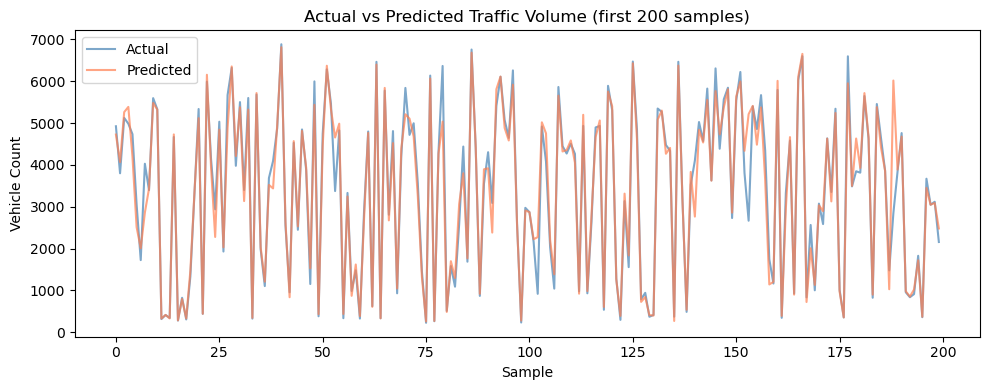

In [57]:
# Plot for Random Forest (likely your best model)
plt.figure(figsize=(10, 4))
plt.plot(y_test.values[:200], label='Actual',    color='steelblue', alpha=0.7)
plt.plot(y_pred_rf[:200],     label='Predicted', color='coral',     alpha=0.7)
plt.title("Actual vs Predicted Traffic Volume (first 200 samples)")
plt.xlabel("Sample")
plt.ylabel("Vehicle Count")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\rdey1\AppData\Local\Temp\ipykernel_26300\3818773790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')


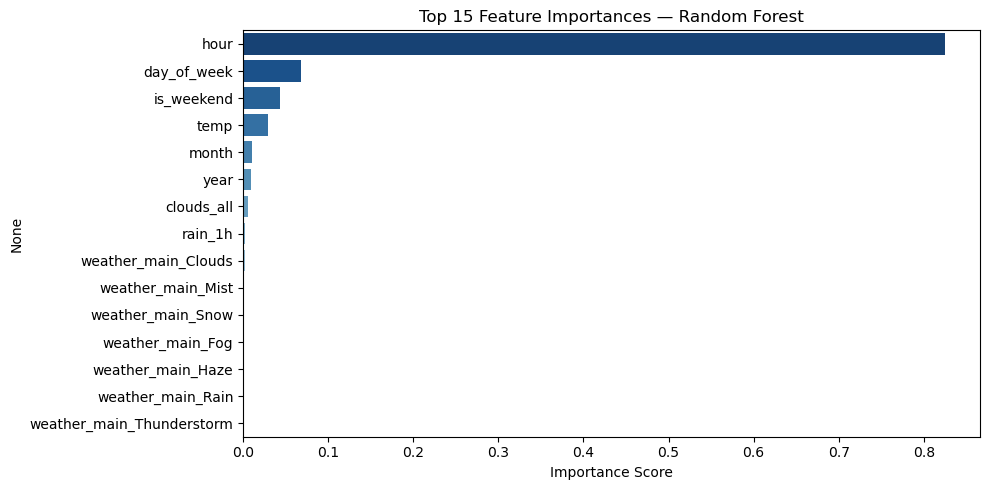

In [58]:
importances = pd.Series(rf.feature_importances_, index=x_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [59]:
# Random Forest is almost certainly your best model
joblib.dump(rf, "models/model.pkl")
print("Model saved to models/model.pkl ✅")

Model saved to models/model.pkl ✅


In [60]:
from sklearn.ensemble import RandomForestRegressor

rf_tuned = RandomForestRegressor(
    n_estimators=200,      # more trees = more stable (was 100)
    max_depth=20,          # limits tree depth to avoid overfitting
    min_samples_split=5,   # minimum samples needed to split a node
    min_samples_leaf=2,    # minimum samples at each leaf node
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)
print("Tuned model trained! ✅")

Tuned model trained! ✅


In [61]:
y_pred_tuned = rf_tuned.predict(x_test)

mae_t  = mean_absolute_error(y_test, y_pred_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_t   = r2_score(y_test, y_pred_tuned)

print("---- Original Random Forest ----")
print(f"MAE  : {mae:.2f}  |  RMSE : {rmse:.2f}  |  R² : {r2:.4f}")
print("\n---- Tuned Random Forest ----")
print(f"MAE  : {mae_t:.2f}  |  RMSE : {rmse_t:.2f}  |  R² : {r2_t:.4f}")

---- Original Random Forest ----
MAE  : 355.17  |  RMSE : 541.72  |  R² : 0.9266

---- Tuned Random Forest ----
MAE  : 223.99  |  RMSE : 408.85  |  R² : 0.9582


C:\Users\rdey1\AppData\Local\Temp\ipykernel_26300\126408877.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')


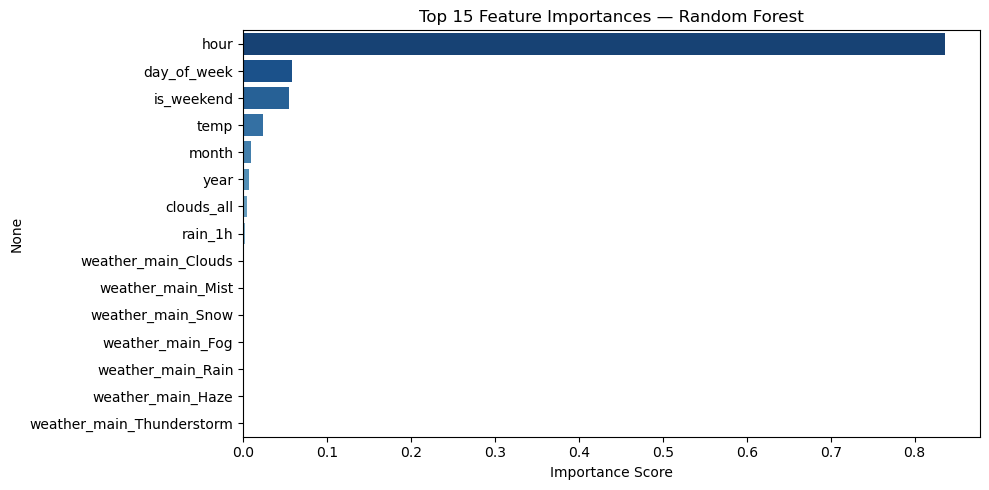

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.Series(rf_tuned.feature_importances_, index=x_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [63]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Save whichever performed better — tuned or original
best_model = rf_tuned   # change to rf if original was better

joblib.dump(best_model, "models/model.pkl")
print("Best model saved! ✅")

Best model saved! ✅


In [64]:
import os

files = os.listdir("models/")
print("Files in models/ folder:")
for f in files:
    print(f"  ✅ {f}")





Files in models/ folder:
  ✅ feature_columns.pkl
  ✅ model.pkl
  ✅ scaler.pkl


In [66]:
# Load saved objects
model    = joblib.load("models/model.pkl")
scaler   = joblib.load("models/scaler.pkl")
feat_cols = joblib.load("models/feature_columns.pkl")

# Simulate a user input
sample = x_test.iloc[[0]]   # take one test row as fake user input

# Predict
prediction = model.predict(sample)
print(f"Predicted traffic volume: {int(prediction[0])} vehicles")
print(f"Actual traffic volume:    {y_test.values[0]} vehicles")

Predicted traffic volume: 4903 vehicles
Actual traffic volume:    4924 vehicles
